In [1]:
# === 1. Imports and basic setup ===
import pandas as pd
import csv
import networkx as nx
from pathlib import Path

# Adjust this if your files are in a different folder
DATA_DIR = Path(".")

# Filenames – change if your Excel files have different names
AIRPORT_ATTR_FILE = DATA_DIR / "Airport_attributes.xlsx"
AIRPORT_NET_FILE = DATA_DIR / "Airport_network_data.xlsx"


In [2]:
# === 2. Parse Airport_attributes ===

# Read the Excel file; all data are in the first column
air_raw = pd.read_excel(AIRPORT_ATTR_FILE, header=None)[0].astype(str)

# Drop completely empty lines if there are any
air_raw = air_raw[air_raw.str.strip() != ""]

# Define the column names we want
airport_cols = [
    "airport_id", "name", "city", "country",
    "iata_faa", "icao", "latitude", "longitude",
    "altitude", "timezone", "dst"
]

def parse_airport_line(line: str):
    """
    Parse a single line like:
    1 "Goroka" "Goroka" "Papua New Guinea" "GKA" "AYGA" -6.081689 145.391881 5282 10 "U"
    into a list of fields.
    """
    # csv.reader handles the quotes around strings with spaces
    return next(csv.reader(
        [line],
        delimiter=" ",      # fields separated by spaces
        quotechar='"',      # quoted fields may contain spaces
        skipinitialspace=True
    ))

# First row in your sheet looks like a header; we skip it
parsed_airports = [parse_airport_line(line) for line in air_raw.iloc[1:]]

# Build DataFrame
airports = pd.DataFrame(parsed_airports, columns=airport_cols)

# Replace OpenFlights-style missing values if they appear
airports = airports.replace({"\\N": pd.NA})

# Convert numeric columns
numeric_cols = ["airport_id", "latitude", "longitude", "altitude", "timezone"]
for col in numeric_cols:
    airports[col] = pd.to_numeric(airports[col], errors="coerce")

# Quick sanity check
print(airports.head())
print(airports.dtypes)


   airport_id                        name          city           country  \
0           1                      Goroka        Goroka  Papua New Guinea   
1           2                      Madang        Madang  Papua New Guinea   
2           3                 Mount Hagen   Mount Hagen  Papua New Guinea   
3           4                      Nadzab        Nadzab  Papua New Guinea   
4           5  Port Moresby Jacksons Intl  Port Moresby  Papua New Guinea   

  iata_faa  icao  latitude   longitude  altitude  timezone dst  
0      GKA  AYGA -6.081689  145.391881      5282      10.0   U  
1      MAG  AYMD -5.207083  145.788700        20      10.0   U  
2      HGU  AYMH -5.826789  144.295861      5388      10.0   U  
3      LAE  AYNZ -6.569828  146.726242       239      10.0   U  
4      POM  AYPY -9.443383  147.220050       146      10.0   U  
airport_id      int64
name           object
city           object
country        object
iata_faa       object
icao           object
latitude      f

In [3]:
# === 3. Parse Airport_network_data and build graph ===

# Read the Excel file; again, everything is in the first column
net_raw = pd.read_excel(AIRPORT_NET_FILE, header=None)[0].astype(str)

# Drop empty lines
net_raw = net_raw[net_raw.str.strip() != ""]

# Skip the first four meta-lines: dl, N=..., format=..., data:
edge_lines = net_raw.iloc[4:]

def parse_edge_line(line: str):
    """
    Parse a line like '1 5 1' into (u, v, w).
    Returns None for malformed lines.
    """
    parts = line.strip().split()
    if len(parts) != 3:
        return None
    u, v, w = parts
    return int(u), int(v), int(w)

edge_tuples = [parse_edge_line(line) for line in edge_lines]
# Drop any None rows just in case
edge_tuples = [e for e in edge_tuples if e is not None]

edges = pd.DataFrame(edge_tuples, columns=["source", "target", "weight"])

# If the file contains duplicate (source, target) pairs, aggregate them
edges = (
    edges
    .groupby(["source", "target"], as_index=False)["weight"]
    .sum()
)

print(edges.head())
print(edges.describe())


   source  target  weight
0       1       5       1
1       2       4       1
2       2       5       1
3       2       6       2
4       2    5430       1
             source        target        weight
count  30501.000000  30501.000000  30501.000000
mean    2503.545785   2501.372873      1.457690
std     1633.094035   1633.049132      0.866057
min        1.000000      1.000000      1.000000
25%     1212.000000   1212.000000      1.000000
50%     2359.000000   2359.000000      1.000000
75%     3576.000000   3576.000000      2.000000
max     7976.000000   7976.000000     11.000000


In [4]:
# Build an undirected weighted graph
G = nx.Graph()

# Add nodes with attributes from airports table
for _, row in airports.iterrows():
    node_id = int(row["airport_id"])
    attrs = row.to_dict()
    G.add_node(node_id, **attrs)

# Add edges with weights
for _, row in edges.iterrows():
    u, v, w = int(row["source"]), int(row["target"]), int(row["weight"])
    if G.has_edge(u, v):
        # Just in case there are still duplicates
        G[u][v]["weight"] += w
    else:
        G.add_edge(u, v, weight=w)

print(f"Number of nodes in G: {G.number_of_nodes()}")
print(f"Number of edges in G: {G.number_of_edges()}")

# Optional: check basic connected components
components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")
print(f"Size of largest component: {len(max(components, key=len))}")


Number of nodes in G: 6630
Number of edges in G: 15677
Number of connected components: 3702
Size of largest component: 2905


In [5]:
# === 4. Work on the largest connected component (G_cc) ===

# Find connected components
components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")

largest_cc_nodes = max(components, key=len)
print(f"Size of largest component: {len(largest_cc_nodes)}")

# Induced subgraph on the largest component
G_cc = G.subgraph(largest_cc_nodes).copy()
print(f"G_cc nodes: {G_cc.number_of_nodes()}, edges: {G_cc.number_of_edges()}")


Number of connected components: 3702
Size of largest component: 2905
G_cc nodes: 2905, edges: 15645


In [6]:
# === 5. Compute node accessibility and global efficiency on G_cc ===

n_cc = G_cc.number_of_nodes()

# Prepare dict to accumulate sums of 1/d(i,j) for each source node
node_sum_inv_dist = {node: 0.0 for node in G_cc.nodes()}

# Iterate over all sources and their shortest-path lengths
for src, lengths in nx.all_pairs_shortest_path_length(G_cc):
    # lengths is a dict: {target: distance}
    for tgt, d in lengths.items():
        if src == tgt:
            continue
        node_sum_inv_dist[src] += 1.0 / d

# Turn sums into accessibility values
node_accessibility = {}
for node, s in node_sum_inv_dist.items():
    node_accessibility[node] = s / (n_cc - 1)

# Global efficiency is just the average of node accessibilities
global_efficiency = sum(node_accessibility.values()) / n_cc

print(f"Global efficiency A(G_cc): {global_efficiency:.6f}")

# Put node accessibility into a DataFrame
acc_df = (
    pd.Series(node_accessibility, name="accessibility")
    .rename_axis("airport_id")
    .reset_index()
)

print(acc_df.head())


Global efficiency A(G_cc): 0.266934
   airport_id  accessibility
0           1       0.234212
1           2       0.234900
2           3       0.235073
3           4       0.234900
4           5       0.313255


In [7]:
# === 6. Combine airport attributes with accessibility, then aggregate by country ===

# Mark which airports are in the main component
airports["in_giant_component"] = airports["airport_id"].isin(G_cc.nodes())

# Merge accessibility values (only defined on G_cc)
airport_metrics = airports.merge(acc_df, how="left", on="airport_id")

print(airport_metrics.head())

# Country-level accessibility: average ai(G) over airports in the country (within G_cc)
country_metrics = (
    airport_metrics[airport_metrics["in_giant_component"] & airport_metrics["accessibility"].notna()]
    .groupby("country", as_index=False)
    .agg(
        n_airports=("airport_id", "count"),
        mean_accessibility=("accessibility", "mean")
    )
    .sort_values("mean_accessibility", ascending=False)
)

print(country_metrics.head(10))

# (Optional) save to CSV for later use
# airport_metrics.to_csv("airport_metrics_accessibility.csv", index=False)
# country_metrics.to_csv("country_metrics_accessibility.csv", index=False)


   airport_id                        name          city           country  \
0           1                      Goroka        Goroka  Papua New Guinea   
1           2                      Madang        Madang  Papua New Guinea   
2           3                 Mount Hagen   Mount Hagen  Papua New Guinea   
3           4                      Nadzab        Nadzab  Papua New Guinea   
4           5  Port Moresby Jacksons Intl  Port Moresby  Papua New Guinea   

  iata_faa  icao  latitude   longitude  altitude  timezone dst  \
0      GKA  AYGA -6.081689  145.391881      5282      10.0   U   
1      MAG  AYMD -5.207083  145.788700        20      10.0   U   
2      HGU  AYMH -5.826789  144.295861      5388      10.0   U   
3      LAE  AYNZ -6.569828  146.726242       239      10.0   U   
4      POM  AYPY -9.443383  147.220050       146      10.0   U   

   in_giant_component  accessibility  
0                True       0.234212  
1                True       0.234900  
2                True  

In [8]:
# === 7a. Add degrees on G_cc ===
deg_series = pd.Series(dict(G_cc.degree()), name="degree")
deg_df = deg_series.rename_axis("airport_id").reset_index()

airport_metrics = airport_metrics.merge(deg_df, on="airport_id", how="left")

# === 7b. Summary of accessibility (only giant component) ===
acc_gc = airport_metrics.loc[airport_metrics["in_giant_component"], "accessibility"]
print("Accessibility summary (giant component only):")
print(acc_gc.describe())

# Correlation between degree and accessibility
corr_deg_acc = airport_metrics["degree"].corr(airport_metrics["accessibility"])
print(f"\nCorrelation(degree, accessibility) = {corr_deg_acc:.3f}")

# === 7c. Top 10 airports by accessibility ===
top10 = (
    airport_metrics[airport_metrics["in_giant_component"]]
    .nlargest(10, "accessibility")
    [["airport_id", "name", "city", "country", "degree", "accessibility"]]
)

print("\nTop 10 airports by accessibility:")
print(top10.to_string(index=False))


Accessibility summary (giant component only):
count    2905.000000
mean        0.266934
std         0.048846
min         0.099854
25%         0.234900
50%         0.265922
75%         0.295502
max         0.462030
Name: accessibility, dtype: float64

Correlation(degree, accessibility) = 0.691

Top 10 airports by accessibility:
 airport_id                  name      city              country  degree  accessibility
        340        Frankfurt Main Frankfurt              Germany   242.0       0.462030
       1382     Charles De Gaulle     Paris               France   218.0       0.452656
        580              Schiphol Amsterdam          Netherlands   211.0       0.446320
        507              Heathrow    London       United Kingdom   159.0       0.443360
       2188            Dubai Intl     Dubai United Arab Emirates   166.0       0.438549
       3797   John F Kennedy Intl  New York        United States   144.0       0.433504
       1555             Fiumicino      Rome            

In [8]:
# === 8. Random failure simulations on G_cc ===

import random
import numpy as np

# We will work on G_cc as the "base" graph
BASE_G = G_cc.copy()
n_base = BASE_G.number_of_nodes()

# Baseline global efficiency A(G)
A_base = nx.global_efficiency(BASE_G)
print(f"\nBaseline global efficiency on G_cc: A(G) = {A_base:.6f}")


def simulate_eal_for_p(G, p_frac, num_trials=200, seed=123):
    """
    Simulate random node failures for a given removal fraction p_frac (e.g. 0.01 for 1%).

    Returns:
        summary dict with EAL, rEAL, SE, 5% tail of losses, etc.
    """
    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    n = len(nodes)
    k = max(1, int(np.floor(p_frac * n)))  # number of nodes to remove each trial

    A_G = nx.global_efficiency(G)

    losses = []
    efficiencies_after = []

    for t in range(num_trials):
        # sample k distinct nodes uniformly at random
        removed = set(random.sample(nodes, k))
        remaining_nodes = [v for v in nodes if v not in removed]

        # induced subgraph after removal
        H = G.subgraph(remaining_nodes)

        # global efficiency after removal
        A_after = nx.global_efficiency(H)
        efficiencies_after.append(A_after)

        # loss L_p(R) = A(G) - A(G\R)
        losses.append(A_G - A_after)

        if (t + 1) % max(1, num_trials // 10) == 0:
            print(f"  p={p_frac:.2%}, trial {t+1}/{num_trials} done")

    losses = np.array(losses)
    efficiencies_after = np.array(efficiencies_after)

    # Sample averages
    mean_A_after = efficiencies_after.mean()
    EAL_hat = A_G - mean_A_after
    rEAL_hat = 1.0 - (mean_A_after / A_G)

    # Standard error of EAL (using losses)
    L_bar = losses.mean()
    sigma_L = losses.std(ddof=1)
    SE_EAL = sigma_L / np.sqrt(num_trials)

    # 5th percentile tail loss (worst cases)
    loss_5pct = np.percentile(losses, 5)

    return {
        "p_frac": p_frac,
        "n": n,
        "k_removed": k,
        "A_G": A_G,
        "mean_A_after": mean_A_after,
        "EAL_hat": EAL_hat,
        "rEAL_hat": rEAL_hat,
        "SE_EAL": SE_EAL,
        "loss_5pct": loss_5pct,
    }


# Run simulations for p ∈ {1%, 5%, 10%}
p_list = [0.01, 0.05, 0.10]
num_trials = 200   # increase to 1000 later if runtime is OK

results = []
for p in p_list:
    print(f"\n=== Simulating for p = {p:.2%} ===")
    res = simulate_eal_for_p(BASE_G, p_frac=p, num_trials=num_trials, seed=123)
    results.append(res)

eal_summary = pd.DataFrame(results)
print("\nEAL / rEAL summary:")
print(eal_summary[[
    "p_frac", "k_removed", "EAL_hat", "SE_EAL", "rEAL_hat", "loss_5pct"
]])



Baseline global efficiency on G_cc: A(G) = 0.266934

=== Simulating for p = 1.00% ===
  p=1.00%, trial 20/200 done
  p=1.00%, trial 40/200 done
  p=1.00%, trial 60/200 done
  p=1.00%, trial 80/200 done
  p=1.00%, trial 100/200 done
  p=1.00%, trial 120/200 done
  p=1.00%, trial 140/200 done
  p=1.00%, trial 160/200 done
  p=1.00%, trial 180/200 done
  p=1.00%, trial 200/200 done

=== Simulating for p = 5.00% ===
  p=5.00%, trial 20/200 done
  p=5.00%, trial 40/200 done
  p=5.00%, trial 60/200 done
  p=5.00%, trial 80/200 done
  p=5.00%, trial 100/200 done
  p=5.00%, trial 120/200 done
  p=5.00%, trial 140/200 done
  p=5.00%, trial 160/200 done
  p=5.00%, trial 180/200 done
  p=5.00%, trial 200/200 done

=== Simulating for p = 10.00% ===
  p=10.00%, trial 20/200 done


KeyboardInterrupt: 

In [10]:
# === 9. Baseline country-level accessibility AC(G) on BASE_G ===

from collections import defaultdict
import numpy as np
import random

# Map airport_id -> country
airport_country_map = (
    airport_metrics
    .set_index("airport_id")["country"]
    .to_dict()
)

def compute_A_and_AC(G, airport_country_map):
    """
    Compute global efficiency A(G) AND country-level accessibility AC(G)
    for an undirected, unweighted graph G.

    Returns
    -------
    A_G : float
        Global efficiency.
    AC_country : dict
        {country -> accessibility AC(G) for that country}.
    """
    n = G.number_of_nodes()
    if n <= 1:
        return 0.0, {}

    global_sum_a = 0.0
    country_sum_a = defaultdict(float)
    country_count = defaultdict(int)

    # All-pairs shortest-path lengths (BFS from each node)
    for src, lengths in nx.all_pairs_shortest_path_length(G):
        s = 0.0
        for tgt, d in lengths.items():
            if src == tgt:
                continue
            s += 1.0 / d

        a_i = s / (n - 1)          # node accessibility in THIS graph
        global_sum_a += a_i

        c = airport_country_map.get(src, None)
        if c is not None:
            country_sum_a[c] += a_i
            country_count[c] += 1

    A_G = global_sum_a / n
    AC_country = {
        c: country_sum_a[c] / country_count[c]
        for c in country_sum_a
        if country_count[c] > 0
    }
    return A_G, AC_country


# Baseline on the current giant component BASE_G
A_base_check, AC_base_country = compute_A_and_AC(BASE_G, airport_country_map)
print(f"Global efficiency from custom function: {A_base_check:.6f}")
print(f"Global efficiency from earlier (nx.global_efficiency): {A_base:.6f}")

# Put baseline country AC in a DataFrame for inspection
AC_base_df = (
    pd.DataFrame(
        [{"country": c, "AC_base": v} for c, v in AC_base_country.items()]
    )
    .sort_values("AC_base", ascending=False)
)

print("\nBaseline country-level accessibility (top 10):")
print(AC_base_df.head(10))


Global efficiency from custom function: 0.266934
Global efficiency from earlier (nx.global_efficiency): 0.266934

Baseline country-level accessibility (top 10):
       country   AC_base
184  Hong Kong  0.410679
133      Qatar  0.407993
197  Singapore  0.407758
77     Hungary  0.375031
205     Latvia  0.372238
13     Belgium  0.363670
122    Bahrain  0.362564
126     Kuwait  0.361281
82       Malta  0.359544
127    Lebanon  0.353014


In [ ]:
# === 10. Simulation function: country-level EAL for a given p ===

def simulate_country_eal_for_p(
    G,
    p_frac,
    airport_country_map,
    AC_base_country,
    num_trials=50,
    seed=123,
):
    """
    Simulate random node removals with fraction p_frac and compute
    country-level EAL.

    Parameters
    ----------
    G : networkx.Graph
        Base graph (use BASE_G).
    p_frac : float
        Fraction of nodes removed in each trial (e.g. 0.05 for 5%).
    airport_country_map : dict
        airport_id -> country.
    AC_base_country : dict
        Baseline AC(G) per country from compute_A_and_AC.
    num_trials : int
        Number of Monte Carlo trials.
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    df : pandas.DataFrame
        Columns: country, AC_base, mean_AC_after, EAL_C_hat,
                 SE_EAL_C, rEAL_C_hat.
    """
    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    n = len(nodes)
    k = max(1, int(np.floor(p_frac * n)))

    countries = list(AC_base_country.keys())
    # store AC(G\R) values for each country over trials
    ac_after = {c: [] for c in countries}

    for t in range(num_trials):
        removed = set(random.sample(nodes, k))
        remaining_nodes = [v for v in nodes if v not in removed]

        # Subgraph after removal
        H = G.subgraph(remaining_nodes).copy()

        # Compute AC on H
        _, AC_trial = compute_A_and_AC(H, airport_country_map)

        # If a country has no airports left in H, treat AC as 0 for that trial
        for c in countries:
            ac_after[c].append(AC_trial.get(c, 0.0))

        if (t + 1) % max(1, num_trials // 10) == 0:
            print(f"  p={p_frac:.2%}, trial {t+1}/{num_trials}")

    # Build result DataFrame
    rows = []
    for c in countries:
        base_ac = AC_base_country[c]
        arr = np.array(ac_after[c])

        mean_after = arr.mean()
        loss = base_ac - mean_after
        se_loss = arr.std(ddof=1) / np.sqrt(num_trials)
        rel_loss = loss / base_ac if base_ac > 0 else np.nan

        rows.append({
            "country": c,
            "AC_base": base_ac,
            "mean_AC_after": mean_after,
            "EAL_C_hat": loss,
            "SE_EAL_C": se_loss,
            "rEAL_C_hat": rel_loss,
        })

    return pd.DataFrame(rows)


In [12]:
# === 11. Run country-level EAL simulations for p = 1%, 5%, 10% ===

p_list = [0.01, 0.05, 0.10]
num_trials_country = 20   # try 20 first; you can raise to 50 or 100 later

country_eal_results = {}

for p in p_list:
    print(f"\n=== Country-level simulations for p = {p:.2%} ===")
    df_p = simulate_country_eal_for_p(
        BASE_G,
        p_frac=p,
        airport_country_map=airport_country_map,
        AC_base_country=AC_base_country,
        num_trials=num_trials_country,
        seed=123,
    )
    country_eal_results[p] = df_p

    # Quick look: 10 most vulnerable countries by relative loss
    top_vuln = (
        df_p.sort_values("rEAL_C_hat", ascending=False)
            .head(10)[["country", "AC_base", "EAL_C_hat", "rEAL_C_hat"]]
    )
    print(top_vuln)

# Example: access the full table for p = 5%
country_eal_5pct = country_eal_results[0.05]
print("\nExample rows for p = 5%:")
print(country_eal_5pct.head())



=== Country-level simulations for p = 1.00% ===
  p=1.00%, trial 2/20
  p=1.00%, trial 4/20
  p=1.00%, trial 6/20
  p=1.00%, trial 8/20
  p=1.00%, trial 10/20
  p=1.00%, trial 12/20
  p=1.00%, trial 14/20
  p=1.00%, trial 16/20
  p=1.00%, trial 18/20
  p=1.00%, trial 20/20
                 country   AC_base  EAL_C_hat  rEAL_C_hat
197            Singapore  0.407758   0.042619    0.104520
51                  Mali  0.249444   0.018082    0.072489
112                Tonga  0.257027   0.014398    0.056019
69                Uganda  0.284175   0.015884    0.055895
184            Hong Kong  0.410679   0.022824    0.055576
101            Nicaragua  0.298122   0.016543    0.055490
33   Congo (Brazzaville)  0.310955   0.017191    0.055285
79              Slovenia  0.341173   0.018838    0.055215
21      Falkland Islands  0.203203   0.011160    0.054922
54          Sierra Leone  0.305897   0.016786    0.054874

=== Country-level simulations for p = 5.00% ===
  p=5.00%, trial 2/20
  p=5.00%, trial

In [13]:
# === 12. Number of airports per country in the giant component ===

# Airports that are actually in BASE_G (i.e., in the giant component)
nodes_in_gc = set(BASE_G.nodes())

airports_gc = airport_metrics[airport_metrics["airport_id"].isin(nodes_in_gc)]

country_counts = (
    airports_gc.groupby("country", as_index=False)
    .agg(n_airports=("airport_id", "count"))
)

print(country_counts.sort_values("n_airports", ascending=False).head(10))


           country  n_airports
214  United States         416
35          Canada         183
41           China         147
26          Brazil         108
10       Australia         102
171         Russia          94
95           India          66
104          Japan          55
71          France          55
133         Mexico          53


In [14]:
# === 13. Merge n_airports into EAL tables and build rankings ===

# We will build ranking tables for each p
rankings_by_p = {}

for p, df_p in country_eal_results.items():
    # Attach number of airports
    df_full = df_p.merge(country_counts, on="country", how="left")

    # Optionally, restrict to countries with at least 3 airports (to avoid tiny, one-node countries)
    df_ge3 = df_full[df_full["n_airports"] >= 3].copy()

    # Most vulnerable: largest relative loss
    top_vulnerable = (
        df_ge3.sort_values("rEAL_C_hat", ascending=False)
              .head(20)
              [["country", "n_airports", "AC_base", "EAL_C_hat", "rEAL_C_hat"]]
    )

    # Safest: smallest relative loss (but still defined)
    safest = (
        df_ge3.sort_values("rEAL_C_hat", ascending=True)
              .head(20)
              [["country", "n_airports", "AC_base", "EAL_C_hat", "rEAL_C_hat"]]
    )

    rankings_by_p[p] = {"full": df_full, "top_vulnerable": top_vulnerable, "safest": safest}

    print(f"\n=== p = {p:.2%} | Top 10 most vulnerable (n_airports >= 3) ===")
    print(top_vulnerable.head(10))

    print(f"\n=== p = {p:.2%} | Top 10 safest (n_airports >= 3) ===")
    print(safest.head(10))



=== p = 1.00% | Top 10 most vulnerable (n_airports >= 3) ===
          country  n_airports   AC_base  EAL_C_hat  rEAL_C_hat
51           Mali           3  0.249444   0.018082    0.072489
152          Peru          19  0.252298   0.012248    0.048547
2         Iceland           5  0.224112   0.007474    0.033350
148      Colombia          51  0.252742   0.007720    0.030546
142   Philippines          39  0.270432   0.008188    0.030277
42     Madagascar          25  0.229411   0.006676    0.029102
68       Tanzania          12  0.257549   0.007341    0.028502
192         Burma          20  0.227587   0.005808    0.025522
30   South Africa           9  0.285926   0.005908    0.020661
64          Kenya          17  0.246618   0.004921    0.019955

=== p = 1.00% | Top 10 safest (n_airports >= 3) ===
                  country  n_airports   AC_base  EAL_C_hat  rEAL_C_hat
92                 Serbia           3  0.306100   0.000226    0.000738
183            Bangladesh           5  0.284951   

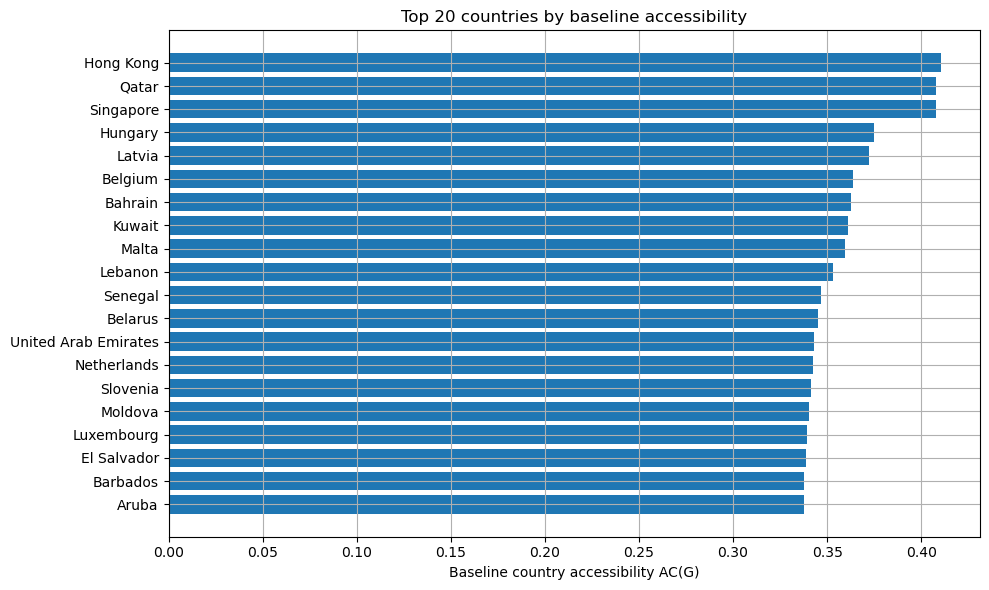

In [15]:
import matplotlib.pyplot as plt

# Optional: make plots a bit bigger by default
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True



# === Figure 1: Top 20 countries by baseline AC(G) ===

topN = 20
top_base = AC_base_df.head(topN)   # already sorted descending

plt.figure()
plt.barh(top_base["country"], top_base["AC_base"])
plt.gca().invert_yaxis()  # highest at top

plt.xlabel("Baseline country accessibility AC(G)")
plt.title("Top 20 countries by baseline accessibility")

plt.tight_layout()
# plt.savefig("fig_top20_baseline_accessibility.png", dpi=300)
plt.show()


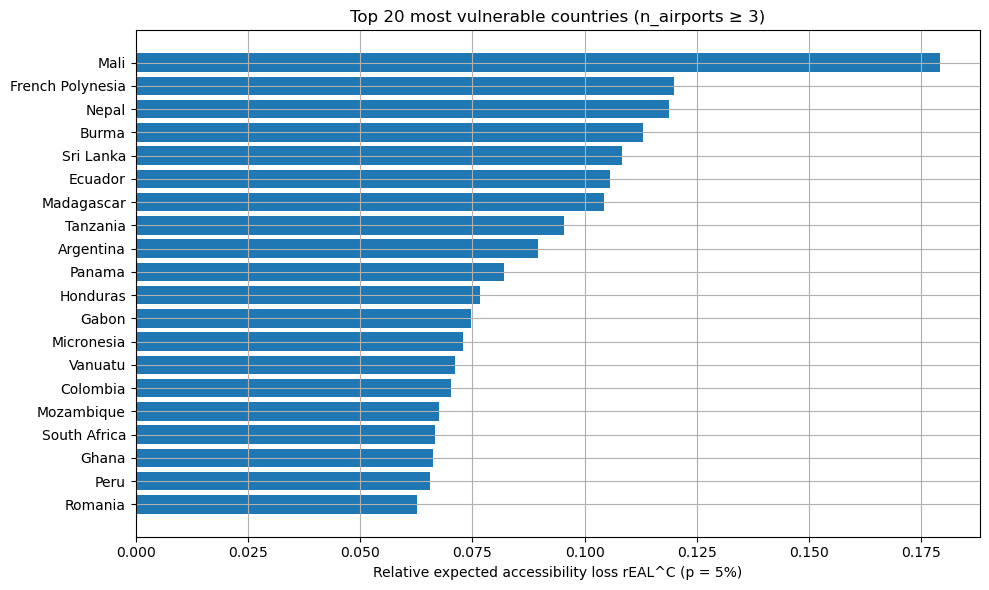

In [16]:
# === Figure 2: Top 20 most vulnerable countries at p = 5% ===

p_main = 0.05
top_vulnerable_5 = rankings_by_p[p_main]["top_vulnerable"]  # from previous code

# Keep only top N if you want fewer bars
topN = 20
top_vuln = top_vulnerable_5.head(topN)

plt.figure()
plt.barh(top_vuln["country"], top_vuln["rEAL_C_hat"])
plt.gca().invert_yaxis()

plt.xlabel("Relative expected accessibility loss rEAL^C (p = 5%)")
plt.title("Top 20 most vulnerable countries (n_airports ≥ 3)")

plt.tight_layout()
# plt.savefig("fig_top20_vulnerable_p05.png", dpi=300)
plt.show()


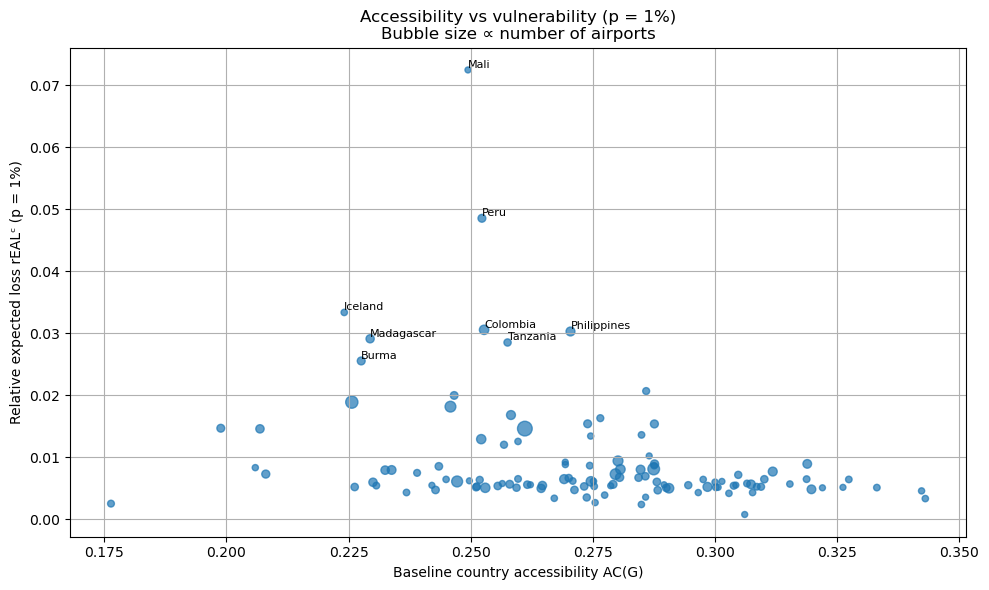

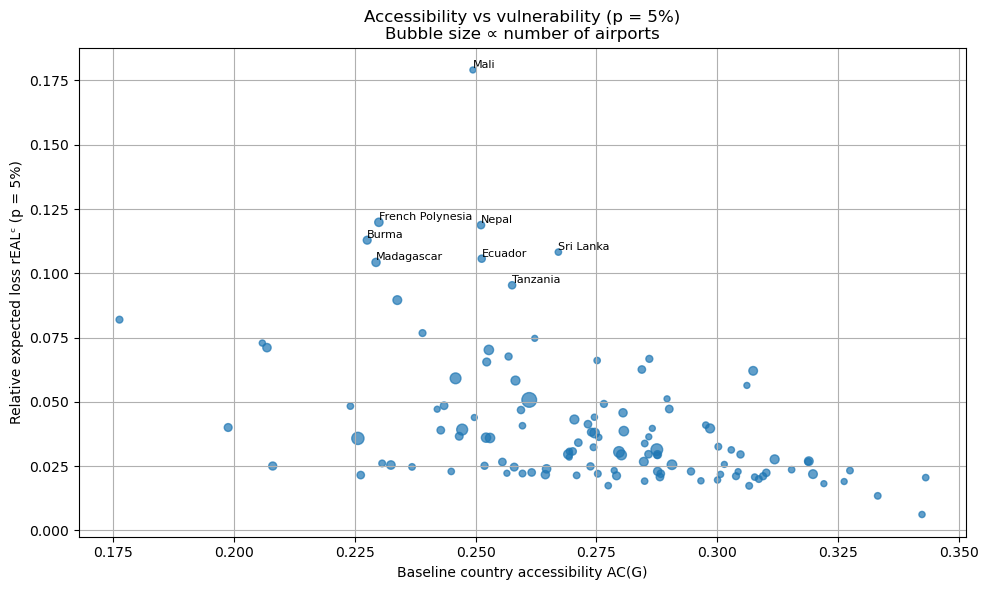

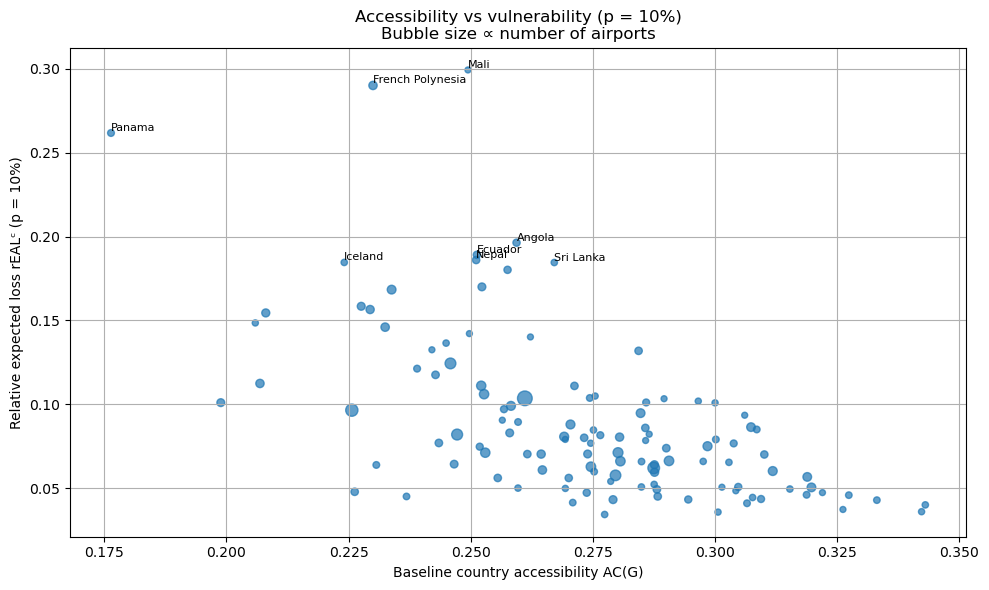

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def scatter_accessibility_vs_vulnerability(p, min_airports=3, top_label_k=8):
    """
    Scatter plot: baseline AC(G) vs rEAL^C at a given p.
    Bubble size ∝ number of airports in the country.
    """

    # Get full table for this p (EAL results + n_airports)
    df_full = rankings_by_p[p]["full"]
    if "n_airports" not in df_full.columns:
        df_full = df_full.merge(country_counts, on="country", how="left")
        rankings_by_p[p]["full"] = df_full  # update stored version

    # Optionally restrict to countries with at least min_airports airports
    df_scatter = df_full[df_full["n_airports"] >= min_airports].copy()

    plt.figure()
    sizes = 10 + 5 * np.sqrt(df_scatter["n_airports"])

    plt.scatter(df_scatter["AC_base"], df_scatter["rEAL_C_hat"],
                s=sizes, alpha=0.7)

    plt.xlabel("Baseline country accessibility AC(G)")
    plt.ylabel(f"Relative expected loss rEAL\u1d9c (p = {p:.0%})")
    plt.title(
        f"Accessibility vs vulnerability (p = {p:.0%})\n"
        "Bubble size \u221d number of airports"
    )

    # Highlight some interesting countries:
    #   - top hubs by AC
    #   - most vulnerable by rEAL at this p
    top_ac_countries = list(AC_base_df.head(top_label_k)["country"])
    top_vuln_countries = list(
        df_scatter.sort_values("rEAL_C_hat", ascending=False)
                  .head(top_label_k)["country"]
    )
    highlight = list(dict.fromkeys(top_ac_countries + top_vuln_countries))

    for _, row in df_scatter[df_scatter["country"].isin(highlight)].iterrows():
        plt.text(row["AC_base"], row["rEAL_C_hat"], row["country"],
                 fontsize=8, ha="left", va="bottom")

    plt.tight_layout()
    plt.show()


# Make the three scatter plots
scatter_accessibility_vs_vulnerability(0.01)
scatter_accessibility_vs_vulnerability(0.05)
scatter_accessibility_vs_vulnerability(0.10)


In [30]:
# === Export country-level metrics for external choropleth maps ===
# Requires: AC_base_df, rankings_by_p already defined.

import pandas as pd

# 1) Baseline accessibility per country
# AC_base_df already has columns: ['country', 'AC_base']
AC_base_df.to_csv("country_baseline_accessibility.csv", index=False)
print("Wrote: country_baseline_accessibility.csv")

# 2) Vulnerability per country for p = 1%, 5%, 10%
for p in [0.01, 0.05, 0.10]:
    label = int(p * 100)  # 1, 5, 10
    df_full = rankings_by_p[p]["full"].copy()

    # Keep only the useful columns for mapping
    out = df_full[["country", "AC_base", "EAL_C_hat", "rEAL_C_hat"]].copy()
    out.to_csv(f"country_vulnerability_p{label}.csv", index=False)
    print(f"Wrote: country_vulnerability_p{label}.csv")


Wrote: country_baseline_accessibility.csv
Wrote: country_vulnerability_p1.csv
Wrote: country_vulnerability_p5.csv
Wrote: country_vulnerability_p10.csv


In [31]:
# === Export nodes and edges of G_cc for ERGM in R ===

import pandas as pd

# Nodes in the giant component
nodes_in_gc = list(G_cc.nodes())

nodes_cc = (
    airport_metrics[airport_metrics["airport_id"].isin(nodes_in_gc)]
    .copy()
)

# Ensure a consistent ordering of nodes
nodes_cc = nodes_cc.sort_values("airport_id").reset_index(drop=True)

# Keep relevant attributes for ERGM
node_export_cols = [
    "airport_id", "name", "city", "country",
    "latitude", "longitude", "degree", "accessibility"
]
nodes_cc[node_export_cols].to_csv("airports_cc_nodes.csv", index=False)
print("Wrote airports_cc_nodes.csv with", len(nodes_cc), "airports.")

# Edges of G_cc (undirected, each pair once)
edges_cc = pd.DataFrame(
    [(u, v) for u, v in G_cc.edges()],
    columns=["from_airport_id", "to_airport_id"]
)
edges_cc.to_csv("airports_cc_edges.csv", index=False)
print("Wrote airports_cc_edges.csv with", len(edges_cc), "edges.")


Wrote airports_cc_nodes.csv with 2905 airports.
Wrote airports_cc_edges.csv with 15645 edges.


In [6]:
import glob
import pandas as pd
import networkx as nx

# List all simulated edgelist files
sim_files = sorted(glob.glob("ergm_sim_edges_*.csv"))
print("Found simulated networks:", sim_files)

# Base node set and attributes from observed G_cc
base_nodes_with_attrs = dict(G_cc.nodes(data=True))
base_node_ids = list(base_nodes_with_attrs.keys())
print("Number of base nodes:", len(base_node_ids))

def build_sim_graph(edge_df):
    """
    Build a simulated graph on the same node set as G_cc,
    then restrict to its largest connected component.
    """
    G_sim = nx.Graph()
    # Add all nodes with original attributes
    for node_id, attrs in base_nodes_with_attrs.items():
        G_sim.add_node(node_id, **attrs)

    # Add edges
    for _, row in edge_df.iterrows():
        u = int(row["from_airport_id"])
        v = int(row["to_airport_id"])
        if u in G_sim and v in G_sim:
            if not G_sim.has_edge(u, v):
                G_sim.add_edge(u, v)

    # Restrict to largest connected component
    if G_sim.number_of_edges() == 0:
        return G_sim  # degenerate case
    comps = list(nx.connected_components(G_sim))
    largest_cc = max(comps, key=len)
    G_sim_cc = G_sim.subgraph(largest_cc).copy()
    return G_sim_cc


Found simulated networks: ['ergm_sim_edges_01.csv', 'ergm_sim_edges_02.csv', 'ergm_sim_edges_03.csv', 'ergm_sim_edges_04.csv', 'ergm_sim_edges_05.csv', 'ergm_sim_edges_06.csv', 'ergm_sim_edges_07.csv', 'ergm_sim_edges_08.csv', 'ergm_sim_edges_09.csv', 'ergm_sim_edges_10.csv', 'ergm_sim_edges_11.csv', 'ergm_sim_edges_12.csv', 'ergm_sim_edges_13.csv', 'ergm_sim_edges_14.csv', 'ergm_sim_edges_15.csv', 'ergm_sim_edges_16.csv', 'ergm_sim_edges_17.csv', 'ergm_sim_edges_18.csv', 'ergm_sim_edges_19.csv', 'ergm_sim_edges_20.csv', 'ergm_sim_edges_21.csv', 'ergm_sim_edges_22.csv', 'ergm_sim_edges_23.csv', 'ergm_sim_edges_24.csv', 'ergm_sim_edges_25.csv', 'ergm_sim_edges_26.csv', 'ergm_sim_edges_27.csv', 'ergm_sim_edges_28.csv', 'ergm_sim_edges_29.csv', 'ergm_sim_edges_30.csv', 'ergm_sim_edges_31.csv', 'ergm_sim_edges_32.csv', 'ergm_sim_edges_33.csv', 'ergm_sim_edges_34.csv', 'ergm_sim_edges_35.csv', 'ergm_sim_edges_36.csv', 'ergm_sim_edges_37.csv', 'ergm_sim_edges_38.csv', 'ergm_sim_edges_39.csv'

In [9]:
import numpy as np

# Use the same p values as before
p_list = [ 0.05]

# Monte Carlo trials for each (p, simulation) pair
num_trials_sim = 50   # adjust upward if runtime is acceptable

sim_results = []

for idx, fname in enumerate(sim_files, start=1):
    print(f"\n=== Processing simulated network {idx}: {fname} ===")
    edge_df = pd.read_csv(fname)

    G_sim_cc = build_sim_graph(edge_df)
    print("Simulated G_cc: nodes =", G_sim_cc.number_of_nodes(),
          "edges =", G_sim_cc.number_of_edges())

    # Baseline efficiency for this simulated network
    A_sim = nx.global_efficiency(G_sim_cc)
    print(f"Baseline efficiency A(G_sim_cc) = {A_sim:.6f}")

    for p in p_list:
        res = simulate_eal_for_p(
            G_sim_cc,
            p_frac=p,
            num_trials=num_trials_sim,
            seed=123 + idx  # change seed per simulation
        )
        res["sim_id"] = idx
        sim_results.append(res)

sim_eal_df = pd.DataFrame(sim_results)
print("\nSimulated EAL summary (first rows):")
print(sim_eal_df.head())



=== Processing simulated network 1: ergm_sim_edges_01.csv ===
Simulated G_cc: nodes = 2458 edges = 16778
Baseline efficiency A(G_sim_cc) = 0.277796
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial 20/50 done
  p=5.00%, trial 25/50 done
  p=5.00%, trial 30/50 done
  p=5.00%, trial 35/50 done
  p=5.00%, trial 40/50 done
  p=5.00%, trial 45/50 done
  p=5.00%, trial 50/50 done

=== Processing simulated network 2: ergm_sim_edges_02.csv ===
Simulated G_cc: nodes = 2456 edges = 16727
Baseline efficiency A(G_sim_cc) = 0.277819
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial 20/50 done
  p=5.00%, trial 25/50 done
  p=5.00%, trial 30/50 done
  p=5.00%, trial 35/50 done
  p=5.00%, trial 40/50 done
  p=5.00%, trial 45/50 done
  p=5.00%, trial 50/50 done

=== Processing simulated network 3: ergm_sim_edges_03.csv ===
Simulated G_cc: nodes = 2464 edges = 16706
Baseline efficiency A(G_sim_cc) = 0.27

Simulated G_cc: nodes = 2406 edges = 16671
Baseline efficiency A(G_sim_cc) = 0.279941
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial 20/50 done
  p=5.00%, trial 25/50 done
  p=5.00%, trial 30/50 done
  p=5.00%, trial 35/50 done
  p=5.00%, trial 40/50 done
  p=5.00%, trial 45/50 done
  p=5.00%, trial 50/50 done

=== Processing simulated network 21: ergm_sim_edges_21.csv ===
Simulated G_cc: nodes = 2371 edges = 16587
Baseline efficiency A(G_sim_cc) = 0.281457
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial 20/50 done
  p=5.00%, trial 25/50 done
  p=5.00%, trial 30/50 done
  p=5.00%, trial 35/50 done
  p=5.00%, trial 40/50 done
  p=5.00%, trial 45/50 done
  p=5.00%, trial 50/50 done

=== Processing simulated network 22: ergm_sim_edges_22.csv ===
Simulated G_cc: nodes = 2413 edges = 16645
Baseline efficiency A(G_sim_cc) = 0.279571
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
 

Baseline efficiency A(G_sim_cc) = 0.279617
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial 20/50 done
  p=5.00%, trial 25/50 done
  p=5.00%, trial 30/50 done
  p=5.00%, trial 35/50 done
  p=5.00%, trial 40/50 done
  p=5.00%, trial 45/50 done
  p=5.00%, trial 50/50 done

=== Processing simulated network 40: ergm_sim_edges_40.csv ===
Simulated G_cc: nodes = 2456 edges = 16772
Baseline efficiency A(G_sim_cc) = 0.277516
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial 20/50 done
  p=5.00%, trial 25/50 done
  p=5.00%, trial 30/50 done
  p=5.00%, trial 35/50 done
  p=5.00%, trial 40/50 done
  p=5.00%, trial 45/50 done
  p=5.00%, trial 50/50 done

=== Processing simulated network 41: ergm_sim_edges_41.csv ===
Simulated G_cc: nodes = 2449 edges = 16768
Baseline efficiency A(G_sim_cc) = 0.276519
  p=5.00%, trial 5/50 done
  p=5.00%, trial 10/50 done
  p=5.00%, trial 15/50 done
  p=5.00%, trial

In [14]:
# Observed EAL summary from earlier
print("\nObserved EAL summary:")
print(sim_eal_df[["p_frac", "k_removed", "EAL_hat", "rEAL_hat"]])

# Aggregate simulated EAL over simulations, for each p
sim_agg = (
    sim_eal_df
    .groupby("p_frac", as_index=False)
    .agg(
        mean_EAL_hat=("EAL_hat", "mean"),
        sd_EAL_hat=("EAL_hat", "std"),
        mean_rEAL_hat=("rEAL_hat", "mean"),
        sd_rEAL_hat=("rEAL_hat", "std")
    )
)

# Merge observed vs ERGM-expected
comparison = sim_eal_df.merge(sim_agg, on="p_frac", how="left")

# Compute "excess" vulnerability: observed minus ERGM-expected
comparison["excess_EAL"] = comparison["EAL_hat"] - comparison["mean_EAL_hat"]
comparison["excess_rEAL"] = comparison["rEAL_hat"] - comparison["mean_rEAL_hat"]

print("\nObserved vs ERGM-expected global EAL:")
print(
    comparison[
        [
            "p_frac", "k_removed",
            "EAL_hat", "mean_EAL_hat", "excess_EAL",
            "rEAL_hat", "mean_rEAL_hat", "excess_rEAL"
        ]
    ]
)



Observed EAL summary:
    p_frac  k_removed   EAL_hat  rEAL_hat
0     0.05        122  0.007864  0.028310
1     0.05        122  0.007777  0.027993
2     0.05        123  0.007577  0.027357
3     0.05        122  0.007727  0.027766
4     0.05        123  0.007732  0.027931
5     0.05        120  0.007391  0.026266
6     0.05        121  0.007663  0.027320
7     0.05        120  0.007930  0.028171
8     0.05        120  0.007750  0.027555
9     0.05        119  0.007439  0.026402
10    0.05        117  0.007405  0.026164
11    0.05        119  0.007379  0.026305
12    0.05        118  0.007206  0.025629
13    0.05        120  0.007772  0.027826
14    0.05        118  0.007585  0.026968
15    0.05        119  0.007414  0.026449
16    0.05        120  0.007432  0.026511
17    0.05        119  0.007316  0.026040
18    0.05        121  0.007407  0.026548
19    0.05        120  0.007546  0.026954
20    0.05        118  0.007321  0.026010
21    0.05        120  0.007679  0.027469
22    0.05 

In [19]:
# Aggregate observed over the 50 trials
obs_agg = (
    sim_eal_df
    .groupby("p_frac", as_index=False)
    .agg(
        EAL_hat_mean  = ("EAL_hat", "mean"),
        EAL_hat_sd    = ("EAL_hat", "std"),
        rEAL_hat_mean = ("rEAL_hat", "mean"),
        rEAL_hat_sd   = ("rEAL_hat", "std"),
    )
)

print("\nAggregated observed global EAL over trials:")
print(obs_agg)

# Merge with sim_agg on p_frac, then compute excess using the *means*
comparison_agg = obs_agg.merge(sim_agg, on="p_frac", how="left")

comparison_agg["excess_EAL_mean"]  = (
    comparison_agg["EAL_hat_mean"] - comparison_agg["mean_EAL_hat"]
)
comparison_agg["excess_rEAL_mean"] = (
    comparison_agg["rEAL_hat_mean"] - comparison_agg["mean_rEAL_hat"]
)

print("\nObserved vs ERGM-expected GLOBAL EAL (aggregated):")
print(
    comparison_agg[
        [
            "p_frac",
            "EAL_hat_mean",  "EAL_hat_sd",
            "mean_EAL_hat",  "sd_EAL_hat",
            "excess_EAL_mean",
            "rEAL_hat_mean", "rEAL_hat_sd",
            "mean_rEAL_hat", "sd_rEAL_hat",
            "excess_rEAL_mean",
        ]
    ]
)



Aggregated observed global EAL over trials:
   p_frac  EAL_hat_mean  EAL_hat_sd  rEAL_hat_mean  rEAL_hat_sd
0    0.05      0.007576    0.000206        0.02716     0.000808

Observed vs ERGM-expected GLOBAL EAL (aggregated):
   p_frac  EAL_hat_mean  EAL_hat_sd  mean_EAL_hat  sd_EAL_hat  \
0    0.05      0.007576    0.000206      0.007576    0.000206   

   excess_EAL_mean  rEAL_hat_mean  rEAL_hat_sd  mean_rEAL_hat  sd_rEAL_hat  \
0              0.0        0.02716     0.000808        0.02716     0.000808   

   excess_rEAL_mean  
0               0.0  


In [25]:
def compute_A_and_AC(G, airport_country_map):
    """
    Compute:
      - A(G): global efficiency of the graph G
      - AC_base_country: baseline country-level accessibility AC^C(G),
        defined as the mean harmonic accessibility of airports in each country.

    Parameters
    ----------
    G : networkx.Graph
        Airport network (typically largest connected component).
    airport_country_map : dict
        Mapping {node_id -> country_code} for all nodes in G.

    Returns
    -------
    A : float
        Global efficiency A(G).
    AC_base_country : pandas.Series
        Index = country, values = AC^C(G).
    """
    # Global efficiency
    A = nx.global_efficiency(G)

    # Node-level accessibility: harmonic centrality on G
    hc = nx.harmonic_centrality(G)  # unweighted shortest paths

    df_nodes = pd.DataFrame({
        "node": list(hc.keys()),
        "accessibility": list(hc.values())
    })
    df_nodes["country"] = df_nodes["node"].map(airport_country_map)

    # Country-level baseline accessibility AC^C(G)
    AC_base = (
        df_nodes
        .groupby("country", as_index=False)["accessibility"]
        .mean()
        .rename(columns={"accessibility": "AC_base"})
    )

    # Return as Series indexed by country
    AC_base_country = AC_base.set_index("country")["AC_base"]

    return A, AC_base_country

def simulate_country_eal_for_p(
    G,
    p_frac,
    airport_country_map,
    AC_base_country,
    num_trials=50,
    seed=None,
):
    """
    Simulate random airport failures at fraction p_frac and compute
    country-level EAL^C and rEAL^C for this graph G.

    Parameters
    ----------
    G : networkx.Graph
        Airport network (largest connected component).
    p_frac : float
        Fraction of airports to remove at random (e.g. 0.05).
    airport_country_map : dict
        Mapping {node_id -> country_code}.
    AC_base_country : pandas.Series
        Baseline AC^C(G) from compute_A_and_AC, index = country.
    num_trials : int
        Number of Monte Carlo failure trials.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    df_out : pandas.DataFrame
        Columns: ["country", "EAL_C_hat", "rEAL_C_hat"].
        One row per country.
    """
    rng = np.random.default_rng(seed)
    all_nodes = np.array(list(G.nodes()))
    n = len(all_nodes)

    # how many airports to remove
    k_remove = max(1, int(round(p_frac * n)))

    # accumulate per-trial losses per country
    loss_trials = []

    for t in range(num_trials):
        # sample airports to remove
        removed = rng.choice(all_nodes, size=k_remove, replace=False)

        G_fail = G.copy()
        G_fail.remove_nodes_from(removed)

        # if everything disconnected / no edges, set accessibility to zero
        if G_fail.number_of_nodes() < 2 or G_fail.number_of_edges() == 0:
            AC_trial = pd.Series(0.0, index=AC_base_country.index)
        else:
            # restrict to largest connected component (as in baseline)
            comps = list(nx.connected_components(G_fail))
            largest = max(comps, key=len)
            G_fail_cc = G_fail.subgraph(largest).copy()

            # harmonic accessibility in failed network
            hc_fail = nx.harmonic_centrality(G_fail_cc)

            df_nodes_fail = pd.DataFrame({
                "node": list(hc_fail.keys()),
                "accessibility": list(hc_fail.values())
            })
            df_nodes_fail["country"] = df_nodes_fail["node"].map(airport_country_map)

            AC_trial = (
                df_nodes_fail
                .groupby("country")["accessibility"]
                .mean()
            )

            # ensure we have all countries present, fill missing with 0
            AC_trial = AC_trial.reindex(AC_base_country.index, fill_value=0.0)

        # loss in accessibility for this trial
        loss = AC_base_country - AC_trial
        loss_trials.append(loss.to_frame(name=f"trial_{t}"))

    # concatenate trials: index = country, columns = trial_0, trial_1, ...
    loss_mat = pd.concat(loss_trials, axis=1)

    # mean loss per country = EAL^C_hat
    EAL_C_hat = loss_mat.mean(axis=1)

    # relative loss rEAL^C_hat
    rEAL_C_hat = EAL_C_hat / AC_base_country

    df_out = pd.DataFrame({
        "country": AC_base_country.index,
        "EAL_C_hat": EAL_C_hat.values,
        "rEAL_C_hat": rEAL_C_hat.values,
    })

    return df_out

In [23]:
# Build mapping: node_id -> country
airport_country_map = {
    node_id: attrs["country"]
    for node_id, attrs in G_cc.nodes(data=True)
}

# Optional sanity check
print("Number of entries in airport_country_map:", len(airport_country_map))
print(list(airport_country_map.items())[:5])



Number of entries in airport_country_map: 2905
[(1, 'Papua New Guinea'), (2, 'Papua New Guinea'), (3, 'Papua New Guinea'), (4, 'Papua New Guinea'), (5, 'Papua New Guinea')]


In [26]:
import glob
import pandas as pd
import networkx as nx
import numpy as np

# If not already defined:
# List all simulated edgelist files from R
sim_files = sorted(glob.glob("ergm_sim_edges_*.csv"))
print("Found simulated networks:", sim_files)

# Node set and attributes from observed G_cc
base_nodes_with_attrs = dict(G_cc.nodes(data=True))

def build_sim_graph(edge_df):
    """
    Build a simulated graph on the same node set as G_cc
    and return its largest connected component.
    """
    G_sim = nx.Graph()
    for node_id, attrs in base_nodes_with_attrs.items():
        G_sim.add_node(node_id, **attrs)

    for _, row in edge_df.iterrows():
        u = int(row["from_airport_id"])
        v = int(row["to_airport_id"])
        if u in G_sim and v in G_sim and not G_sim.has_edge(u, v):
            G_sim.add_edge(u, v)

    if G_sim.number_of_edges() == 0:
        return G_sim

    comps = list(nx.connected_components(G_sim))
    largest_cc = max(comps, key=len)
    return G_sim.subgraph(largest_cc).copy()


# Parameters for the country-level failure simulation
p_list = [0.05]
num_trials_country_sim = 50  # per (p, simulation) pair; adjust if needed

sim_country_results = []

for idx, fname in enumerate(sim_files, start=1):
    print(f"\n=== Country-level EAL for simulated network {idx}: {fname} ===")
    edge_df = pd.read_csv(fname)
    G_sim_cc = build_sim_graph(edge_df)

    print("Simulated G_cc: nodes =", G_sim_cc.number_of_nodes(),
          "edges =", G_sim_cc.number_of_edges())

    # Baseline A(G) and country AC(G) for this simulated network
    A_sim, AC_base_sim = compute_A_and_AC(G_sim_cc, airport_country_map)
    print(f"Baseline efficiency A(G_sim_cc) = {A_sim:.6f}")

    for p in p_list:
        df_sim_p = simulate_country_eal_for_p(
            G_sim_cc,
            p_frac=p,
            airport_country_map=airport_country_map,
            AC_base_country=AC_base_sim,
            num_trials=num_trials_country_sim,
            seed=123 + idx  # change seed per simulation
        )
        df_sim_p["sim_id"] = idx
        df_sim_p["p_frac"] = p
        sim_country_results.append(df_sim_p)

# Combine results from all simulations
sim_country_eal_df = pd.concat(sim_country_results, ignore_index=True)
print("\nSimulated country-level EAL (first rows):")
print(sim_country_eal_df.head())


Found simulated networks: ['ergm_sim_edges_01.csv', 'ergm_sim_edges_02.csv', 'ergm_sim_edges_03.csv', 'ergm_sim_edges_04.csv', 'ergm_sim_edges_05.csv', 'ergm_sim_edges_06.csv', 'ergm_sim_edges_07.csv', 'ergm_sim_edges_08.csv', 'ergm_sim_edges_09.csv', 'ergm_sim_edges_10.csv', 'ergm_sim_edges_11.csv', 'ergm_sim_edges_12.csv', 'ergm_sim_edges_13.csv', 'ergm_sim_edges_14.csv', 'ergm_sim_edges_15.csv', 'ergm_sim_edges_16.csv', 'ergm_sim_edges_17.csv', 'ergm_sim_edges_18.csv', 'ergm_sim_edges_19.csv', 'ergm_sim_edges_20.csv', 'ergm_sim_edges_21.csv', 'ergm_sim_edges_22.csv', 'ergm_sim_edges_23.csv', 'ergm_sim_edges_24.csv', 'ergm_sim_edges_25.csv', 'ergm_sim_edges_26.csv', 'ergm_sim_edges_27.csv', 'ergm_sim_edges_28.csv', 'ergm_sim_edges_29.csv', 'ergm_sim_edges_30.csv', 'ergm_sim_edges_31.csv', 'ergm_sim_edges_32.csv', 'ergm_sim_edges_33.csv', 'ergm_sim_edges_34.csv', 'ergm_sim_edges_35.csv', 'ergm_sim_edges_36.csv', 'ergm_sim_edges_37.csv', 'ergm_sim_edges_38.csv', 'ergm_sim_edges_39.csv'

Simulated G_cc: nodes = 2451 edges = 16823
Baseline efficiency A(G_sim_cc) = 0.277749

=== Country-level EAL for simulated network 45: ergm_sim_edges_45.csv ===
Simulated G_cc: nodes = 2456 edges = 16792
Baseline efficiency A(G_sim_cc) = 0.275943

=== Country-level EAL for simulated network 46: ergm_sim_edges_46.csv ===
Simulated G_cc: nodes = 2458 edges = 16781
Baseline efficiency A(G_sim_cc) = 0.276388

=== Country-level EAL for simulated network 47: ergm_sim_edges_47.csv ===
Simulated G_cc: nodes = 2468 edges = 16779
Baseline efficiency A(G_sim_cc) = 0.275977

=== Country-level EAL for simulated network 48: ergm_sim_edges_48.csv ===
Simulated G_cc: nodes = 2463 edges = 16741
Baseline efficiency A(G_sim_cc) = 0.276202

=== Country-level EAL for simulated network 49: ergm_sim_edges_49.csv ===
Simulated G_cc: nodes = 2457 edges = 16760
Baseline efficiency A(G_sim_cc) = 0.277598

=== Country-level EAL for simulated network 50: ergm_sim_edges_50.csv ===
Simulated G_cc: nodes = 2451 edges

In [28]:
import pandas as pd

# We already have: airport_country_map = {node_id: country, ...}

airport_df = pd.DataFrame(
    list(airport_country_map.items()),
    columns=["node", "country"]
)

country_counts = (
    airport_df
    .groupby("country", as_index=False)
    .size()
    .rename(columns={"size": "n_airports"})
)

print("Number of countries:", len(country_counts))
print("Min / max n_airports:", country_counts["n_airports"].min(), country_counts["n_airports"].max())
print(country_counts.head())


Number of countries: 226
Min / max n_airports: 1 416
          country  n_airports
0     Afghanistan          10
1         Albania           1
2         Algeria          25
3  American Samoa           1
4          Angola          12


In [30]:
# ----- Empirical country-level EAL for G_cc -----

# 1. Baseline A(G_cc) and AC^C(G_cc) for the observed network
A_emp, AC_base_emp = compute_A_and_AC(G_cc, airport_country_map)
print(f"Baseline efficiency A(G_cc) = {A_emp:.6f}")

# Put AC_base into a small DataFrame for merging later
AC_base_emp_df = (
    AC_base_emp
    .reset_index()
    .rename(columns={"index": "country", "AC_base": "AC_base"})
)

# 2. Choose the same p_list as for structural null
p_list = [0.05]  # make sure this matches your later code

# Number of Monte Carlo trials for the observed network
num_trials_emp = 50

country_eal_results = {}

for p in p_list:
    print(f"\n=== Empirical country-level EAL for p = {p:.0%} ===")
    df_emp_p = simulate_country_eal_for_p(
        G_cc,
        p_frac=p,
        airport_country_map=airport_country_map,
        AC_base_country=AC_base_emp,
        num_trials=num_trials_emp,
        seed=999  # any fixed seed for reproducibility
    )

    # Attach baseline AC^C(G_cc)
    df_emp_p = df_emp_p.merge(AC_base_emp_df, on="country", how="left")

    # Store in dict keyed by p
    country_eal_results[p] = df_emp_p

# Quick sanity check
print("\nEmpirical country-level EAL (first rows) for p = 5%:")
print(country_eal_results[0.05].head())


Baseline efficiency A(G_cc) = 0.266934

=== Empirical country-level EAL for p = 5% ===

Empirical country-level EAL (first rows) for p = 5%:
          country   EAL_C_hat  rEAL_C_hat     AC_base
0     Afghanistan   52.076840    0.071204  731.379095
1         Albania   98.970072    0.105986  933.802778
2         Algeria   54.843504    0.071420  767.902167
3  American Samoa  176.060278    0.236509  744.413492
4          Angola   55.029825    0.073056  753.258333


In [31]:
# Aggregate simulated EAL^C across simulations, for each (p, country)
sim_country_agg = (
    sim_country_eal_df
    .groupby(["p_frac", "country"], as_index=False)
    .agg(
        mean_EAL_C_hat   = ("EAL_C_hat", "mean"),
        sd_EAL_C_hat     = ("EAL_C_hat", "std"),
        mean_rEAL_C_hat  = ("rEAL_C_hat", "mean"),
        sd_rEAL_C_hat    = ("rEAL_C_hat", "std"),
    )
)

# For convenience, add n_airports (from empirical G_cc)
sim_country_agg = sim_country_agg.merge(country_counts, on="country", how="left")

# Countries with at least 3 airports (from empirical network)
countries_keep = set(
    country_counts.loc[country_counts["n_airports"] >= 3, "country"]
)

# Build comparison tables for each p
country_structural_null = {}

for p in p_list:
    print(f"\n=== Country-level structural-null comparison for p = {p:.0%} ===")

    # Observed EAL^C from empirical network, with n_airports
    obs_p = country_eal_results[p].merge(country_counts, on="country", how="left")
    # Keep only countries with >= 3 airports
    obs_p = obs_p[obs_p["country"].isin(countries_keep)].copy()

    # ERGM-expected EAL^C
    sim_p = sim_country_agg[sim_country_agg["p_frac"] == p].copy()
    # Keep only countries with >= 3 airports
    sim_p = sim_p[sim_p["country"].isin(countries_keep)].copy()

    # Merge observed vs ERGM-expected
    cmp_p = obs_p.merge(
        sim_p[["country", "mean_EAL_C_hat", "mean_rEAL_C_hat"]],
        on="country",
        how="left",
        suffixes=("", "_ergm")
    )

    # Excess vulnerability: observed minus ERGM-expected
    cmp_p["excess_EAL_C"]  = cmp_p["EAL_C_hat"]  - cmp_p["mean_EAL_C_hat"]
    cmp_p["excess_rEAL_C"] = cmp_p["rEAL_C_hat"] - cmp_p["mean_rEAL_C_hat"]

    country_structural_null[p] = cmp_p

    # Show top 10 countries that are more fragile than structural null
    more_fragile = (
        cmp_p.sort_values("excess_rEAL_C", ascending=False)
             .head(10)[
                 ["country", "n_airports",
                  "rEAL_C_hat", "mean_rEAL_C_hat", "excess_rEAL_C"]
             ]
    )
    print("\nTop 10 more fragile than structural null:")
    print(more_fragile)

    # Show top 10 more robust
    more_robust = (
        cmp_p.sort_values("excess_rEAL_C", ascending=True)
             .head(10)[
                 ["country", "n_airports",
                  "rEAL_C_hat", "mean_rEAL_C_hat", "excess_rEAL_C"]
             ]
    )
    print("\nTop 10 more robust than structural null:")
    print(more_robust)



=== Country-level structural-null comparison for p = 5% ===

Top 10 more fragile than structural null:
                      country  n_airports  rEAL_C_hat  mean_rEAL_C_hat  \
69                      Nepal          13    0.160239         0.066175   
106  Turks and Caicos Islands           5    0.135898         0.073264   
90            Solomon Islands          22    0.123162         0.065799   
36           French Polynesia          27    0.107721         0.064824   
22               Cook Islands           6    0.106190         0.066595   
63                   Maldives           5    0.103715         0.066132   
40                      Ghana           5    0.101659         0.065042   
8                      Belize           7    0.101038         0.067145   
95                  Sri Lanka           5    0.098617         0.074722   
79           Papua New Guinea          29    0.087498         0.067228   

     excess_rEAL_C  
69        0.094064  
106       0.062634  
90        0.057363

In [32]:
# Export structural-null comparison results for mapping
for p, df in country_structural_null.items():
    p_int = int(round(p * 100))

    # Ensure we only export countries with at least 3 airports
    df_filtered = df[df["country"].isin(countries_keep)].copy()

    out = df_filtered[[
        "country",
        "n_airports",
        "AC_base",
        "EAL_C_hat",
        "rEAL_C_hat",
        "mean_EAL_C_hat",
        "mean_rEAL_C_hat",
        "excess_EAL_C",
        "excess_rEAL_C",
    ]]

    out.to_csv(f"country_structural_null_p{p_int}.csv", index=False)
    print(f"Wrote country_structural_null_p{p_int}.csv")


Wrote country_structural_null_p5.csv
